# 03b · Results Chapter Exports

Converts lower-level network exports into **chapter-ready results tables** and
**publication-quality figures** for the thesis.

## Goals
1. Build a master edge table across all contexts and specifications.
2. Extract the focal neighborhood of `SEVERITY`.
3. Compute embeddedness metrics per context:
   - `S(SEVERITY)` — focal strength (sum of absolute weights incident to SEVERITY)
   - `S_aff` / `S_beh` — affect and behavior components of focal strength
   - `P_aff` / `P_beh` — proportional decomposition
   - `GS` — global strength (sum of absolute weights over all unique undirected edges)
4. Build context-level summary tables for sample sizes, edge counts, and focal neighbors.
5. Export tables and figures for direct use in the Results chapter.

## Reporting principle
All outputs are **descriptive**. No causal interpretation is made.

In [1]:
import math
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

# ── Paths ─────────────────────────────────────────────────────────────────────
CANDIDATE_DIRS = [
    Path("..") / "results" / "networks",
    Path("results") / "networks",
    Path.cwd() / "results" / "networks",
]
NETWORK_DIR = next((d.resolve() for d in CANDIDATE_DIRS if d.exists()), None)
if NETWORK_DIR is None:
    raise FileNotFoundError(
        "Could not find results/networks directory. "
        "Checked: " + ", ".join(str(d) for d in CANDIDATE_DIRS)
    )

EXPORT_DIR = NETWORK_DIR / "chapter_exports"
FIG_DIR    = EXPORT_DIR / "figures"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("NETWORK_DIR:", NETWORK_DIR)
print("EXPORT_DIR :", EXPORT_DIR)
print("FIG_DIR    :", FIG_DIR)

# ── Matplotlib defaults ───────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize"   : (10, 6),
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : False,
})

NETWORK_DIR: C:\Users\Ciinz\Desktop\ThesisFinal\Results\networks
EXPORT_DIR : C:\Users\Ciinz\Desktop\ThesisFinal\Results\networks\chapter_exports
FIG_DIR    : C:\Users\Ciinz\Desktop\ThesisFinal\Results\networks\chapter_exports\figures


In [2]:
# ── Node metadata — explicit constants, not inferred from files ───────────────
FOCAL_NODE = "SEVERITY"

NODE_DOMAIN = {
    "SEVERITY"           : "belief",
    "AFF_FEAR"           : "affect",
    "AFF_WORRY"          : "affect",
    "WORRY_HEALTH_SYSTEM": "affect",
    "USE2_MASK"          : "behavior",
    "USE2_SPACE150"      : "behavior",
    "USE2_HANDWASH20"    : "behavior",
    "USE2_AVOID"         : "behavior",
}

# Canonical node order — must match estimation notebook exactly
NODE_ORDER = [
    "SEVERITY",
    "AFF_FEAR", "AFF_WORRY", "WORRY_HEALTH_SYSTEM",
    "USE2_MASK", "USE2_SPACE150", "USE2_HANDWASH20", "USE2_AVOID",
]

AFFECT_NODES   = [n for n in NODE_ORDER if NODE_DOMAIN[n] == "affect"]
BEHAVIOR_NODES = [n for n in NODE_ORDER if NODE_DOMAIN[n] == "behavior"]
PSY_NODES      = [n for n in NODE_ORDER if NODE_DOMAIN[n] in {"belief", "affect"}]
NODE_ROLE      = {n: ("focal_belief" if n == FOCAL_NODE else "non_focal") for n in NODE_ORDER}

# ── Spec metadata — must match notebooks 02 and 03 exactly ───────────────────
# g05_thr comes FIRST so the regex alternation does not partially match g05.
SPEC_META = {
    "g05_thr"     : {"gamma_ebic": 0.5,  "thresholded": True,  "cor_method": "pearson",  "in_kg": False},
    "g075"        : {"gamma_ebic": 0.75, "thresholded": False, "cor_method": "pearson",  "in_kg": False},
    "g05"         : {"gamma_ebic": 0.5,  "thresholded": False, "cor_method": "pearson",  "in_kg": True},
    "g05_spearman": {"gamma_ebic": 0.5,  "thresholded": False, "cor_method": "spearman", "in_kg": False},
}
# Ordered longest-first for unambiguous regex alternation
SPEC_PATTERN = "|".join(sorted(SPEC_META.keys(), key=lambda s: -len(s)))

print("FOCAL_NODE    :", FOCAL_NODE)
print("AFFECT_NODES  :", AFFECT_NODES)
print("BEHAVIOR_NODES:", BEHAVIOR_NODES)
print("SPEC_PATTERN  :", SPEC_PATTERN)

FOCAL_NODE    : SEVERITY
AFFECT_NODES  : ['AFF_FEAR', 'AFF_WORRY', 'WORRY_HEALTH_SYSTEM']
BEHAVIOR_NODES: ['USE2_MASK', 'USE2_SPACE150', 'USE2_HANDWASH20', 'USE2_AVOID']
SPEC_PATTERN  : g05_spearman|g05_thr|g075|g05


In [3]:
# ── Discover and inventory exported files ─────────────────────────────────────
PAT_EDGES = re.compile(
    rf"^edges_wave(?P<wave>\d+)_trust(?P<trust>low|high)"
    rf"_n(?P<n_cc>\d+)_(?P<spec>{SPEC_PATTERN})\.csv$"
)
PAT_ADJ = re.compile(
    rf"^adj_wave(?P<wave>\d+)_trust(?P<trust>low|high)"
    rf"_n(?P<n_cc>\d+)_(?P<spec>{SPEC_PATTERN})\.csv$"
)

def _parse_file(fname: str, kind: str, pat: re.Pattern) -> dict | None:
    m = pat.match(fname)
    if m is None:
        return None
    spec = m.group("spec")
    return {
        "file"         : fname,
        "kind"         : kind,
        "wave"         : int(m.group("wave")),
        "trust_stratum": m.group("trust"),
        "n_cc"         : int(m.group("n_cc")),
        "thresholded"  : SPEC_META[spec]["thresholded"],
        "spec"         : spec,
    }

all_fnames = sorted(p.name for p in NETWORK_DIR.iterdir() if p.is_file())
edge_records = [r for f in all_fnames if (r := _parse_file(f, "edges",     PAT_EDGES)) is not None]
adj_records  = [r for f in all_fnames if (r := _parse_file(f, "adjacency", PAT_ADJ))   is not None]

if not edge_records:
    raise FileNotFoundError("No edge CSV files matched in " + str(NETWORK_DIR))
if not adj_records:
    raise FileNotFoundError("No adjacency CSV files matched in " + str(NETWORK_DIR))

inventory = (
    pd.DataFrame(edge_records + adj_records)
    .sort_values(["wave", "trust_stratum", "spec", "kind", "file"])
    .reset_index(drop=True)
)

# ── Cross-validate against networks_summary.csv ───────────────────────────────
summary_path = NETWORK_DIR / "networks_summary.csv"
if summary_path.exists():
    net_summary = pd.read_csv(summary_path)
    edge_keys   = pd.DataFrame(edge_records)[["wave","trust_stratum","n_cc","spec"]].drop_duplicates()
    orphans     = edge_keys.merge(
        net_summary[["wave","trust_stratum","n_cc","spec"]].drop_duplicates(),
        on=["wave","trust_stratum","n_cc","spec"], how="left", indicator=True
    ).query('_merge == "left_only"')
    if not orphans.empty:
        warnings.warn(
            f"{len(orphans)} edge file(s) have no matching row in networks_summary.csv:\n"
            + orphans.to_string()
        )
else:
    warnings.warn("networks_summary.csv not found — skipping cross-validation.")

inventory.to_csv(EXPORT_DIR / "inventory_results_files.csv", index=False)

print("Total matched files:", len(inventory))
display(
    inventory.groupby(["kind","spec"], as_index=False)
    .size().rename(columns={"size":"n_files"})
)
display(
    inventory.groupby(["wave","trust_stratum","spec"], as_index=False)
    .agg(
        n_edge_files=("kind", lambda s: int((s == "edges").sum())),
        n_adj_files =("kind", lambda s: int((s == "adjacency").sum())),
        n_cc        =("n_cc", "max"),
    )
    .sort_values(["wave","trust_stratum","spec"])
)

Total matched files: 48


,kind,spec,n_files
0,adjacency,g05,6
1,adjacency,g05_spearman,6
2,adjacency,g05_thr,6
3,adjacency,g075,6
4,edges,g05,6
5,edges,g05_spearman,6
6,edges,g05_thr,6
7,edges,g075,6


,wave,trust_stratum,spec,n_edge_files,n_adj_files,n_cc
0,55,high,g05,1,1,309
1,55,high,g05_spearman,1,1,309
2,55,high,g05_thr,1,1,309
3,55,high,g075,1,1,309
4,55,low,g05,1,1,376
5,55,low,g05_spearman,1,1,376
6,55,low,g05_thr,1,1,376
7,55,low,g075,1,1,376
8,56,high,g05,1,1,351
9,56,high,g05_spearman,1,1,351


In [4]:
# ── Build master edge table ───────────────────────────────────────────────────
# Edge CSV files from the R estimation notebook contain UPPER-TRIANGLE edges only
# (from < to, lexicographic), so each undirected edge appears exactly once.
# No deduplication is needed, but we verify this with an assertion below.

def _load_edge_file(rec: dict) -> pd.DataFrame:
    df = pd.read_csv(NETWORK_DIR / rec["file"])
    missing = {"from","to","weight"} - set(df.columns)
    if missing:
        raise ValueError(f"{rec['file']} is missing columns: {missing}")
    df = df.copy()
    for k, v in rec.items():
        if k != "file":
            df[k] = v
    df["abs_weight"]  = df["weight"].abs()
    # Canonical undirected key: alphabetic min -- max
    df["edge_key"]    = [f"{min(a,b)} -- {max(a,b)}"
                         for a, b in zip(df["from"], df["to"])]
    df["from_domain"] = df["from"].map(NODE_DOMAIN)
    df["to_domain"]   = df["to"].map(NODE_DOMAIN)
    df["from_role"]   = df["from"].map(NODE_ROLE)
    df["to_role"]     = df["to"].map(NODE_ROLE)
    df["is_focal_edge"]          = (df["from"] == FOCAL_NODE) | (df["to"] == FOCAL_NODE)
    df["is_affect_affect"]       = (df["from_domain"] == "affect")   & (df["to_domain"] == "affect")
    df["is_behavior_behavior"]   = (df["from_domain"] == "behavior") & (df["to_domain"] == "behavior")
    df["is_belief_affect"]       = (
        ((df["from_domain"] == "belief") & (df["to_domain"] == "affect")) |
        ((df["from_domain"] == "affect") & (df["to_domain"] == "belief"))
    )
    df["is_belief_behavior"]     = (
        ((df["from_domain"] == "belief")   & (df["to_domain"] == "behavior")) |
        ((df["from_domain"] == "behavior") & (df["to_domain"] == "belief"))
    )
    df["is_affect_behavior"]     = (
        ((df["from_domain"] == "affect")   & (df["to_domain"] == "behavior")) |
        ((df["from_domain"] == "behavior") & (df["to_domain"] == "affect"))
    )
    return df

master_edges = pd.concat(
    [_load_edge_file(r) for r in edge_records],
    ignore_index=True
)

PREFERRED_COLS = [
    "wave","trust_stratum","spec","thresholded","n_cc",
    "from","to","edge_key","weight","abs_weight",
    "from_domain","to_domain","from_role","to_role",
    "is_focal_edge","is_affect_affect","is_behavior_behavior",
    "is_belief_affect","is_belief_behavior","is_affect_behavior",
]
other_cols   = [c for c in master_edges.columns if c not in PREFERRED_COLS]
master_edges = master_edges[PREFERRED_COLS + other_cols]

# ── Deduplicate symmetric pairs ───────────────────────────────────────────────
# If edge CSVs contain the full symmetric matrix (both i→j and j→i) instead
# of upper-triangle only, the canonical edge_key (min--max) maps both to the
# same key.  Deduplicate here, keeping the first occurrence per context × key.
n_before = len(master_edges)
master_edges = (
    master_edges
    .sort_values(["wave","trust_stratum","spec","abs_weight"], ascending=[True,True,True,False])
    .drop_duplicates(subset=["wave","trust_stratum","spec","edge_key"], keep="first")
    .reset_index(drop=True)
)
n_dropped = n_before - len(master_edges)
if n_dropped > 0:
    import warnings
    warnings.warn(
        f"Deduplicated {n_dropped} symmetric-duplicate rows "
        "(edge files contained full matrix instead of upper triangle)."
    )

# Sanity: no duplicate edges should remain
dup_check = (
    master_edges
    .groupby(["wave","trust_stratum","spec","edge_key"])
    .size()
    .loc[lambda s: s > 1]
)
if not dup_check.empty:
    raise ValueError(
        f"{len(dup_check)} duplicate edge_key values remain after deduplication.\n"
        + str(dup_check.head())
    )

master_edges.to_csv(EXPORT_DIR / "master_edges_all_contexts.csv", index=False)
print("Master edge table:", master_edges.shape,
      "| unique contexts:", master_edges[["wave","trust_stratum","spec"]].drop_duplicates().shape[0])

display(
    master_edges.groupby(["wave","trust_stratum","spec"], as_index=False).agg(
        n_edges        =("weight",     "size"),
        n_nonzero      =("weight",     lambda s: int((s != 0).sum())),
        mean_abs_weight=("abs_weight", "mean"),
        max_abs_weight =("abs_weight", "max"),
    ).sort_values(["wave","trust_stratum","spec"])
)

Master edge table: (672, 21) | unique contexts: 24


,wave,trust_stratum,spec,n_edges,n_nonzero,mean_abs_weight,max_abs_weight
0,55,high,g05,28,25,0.105302,0.577395
1,55,high,g05_spearman,28,23,0.095955,0.539987
2,55,high,g05_thr,28,9,0.078273,0.596642
3,55,high,g075,28,23,0.093472,0.551529
4,55,low,g05,28,23,0.113482,0.552748
5,55,low,g05_spearman,28,23,0.119052,0.557739
6,55,low,g05_thr,28,14,0.106120,0.570062
7,55,low,g075,28,23,0.113482,0.552748
8,56,high,g05,28,21,0.094851,0.531144
9,56,high,g05_spearman,28,22,0.100370,0.548622


In [5]:
# ── Focal neighborhood: edges incident to SEVERITY ────────────────────────────
focal_edges = master_edges.loc[master_edges["is_focal_edge"]].copy()

focal_edges["neighbor"] = np.where(
    focal_edges["from"] == FOCAL_NODE,
    focal_edges["to"],
    focal_edges["from"],
)
focal_edges["neighbor_domain"] = focal_edges["neighbor"].map(NODE_DOMAIN)

# Sort descending by abs_weight within each context so rank 1 = strongest neighbor
focal_edges = (
    focal_edges
    .sort_values(["wave","trust_stratum","spec","abs_weight"], ascending=[True,True,True,False])
    .reset_index(drop=True)
)

# Rank within context — method="first" breaks ties by row order (i.e. file order)
focal_edges["focal_rank_within_context"] = (
    focal_edges
    .groupby(["wave","trust_stratum","spec"])["abs_weight"]
    .rank(method="first", ascending=False)
    .astype(int)
)

focal_edges.to_csv(EXPORT_DIR / "focal_edges_severity.csv", index=False)
print("focal_edges_severity.csv:", focal_edges.shape)

# Warn if SEVERITY is isolated in any context
isolated_contexts = (
    master_edges[["wave","trust_stratum","spec"]].drop_duplicates()
    .merge(
        focal_edges[["wave","trust_stratum","spec"]].drop_duplicates(),
        on=["wave","trust_stratum","spec"], how="left", indicator=True
    )
    .query('_merge == "left_only"')[["wave","trust_stratum","spec"]]
)
if not isolated_contexts.empty:
    warnings.warn(
        "SEVERITY has no edges in the following context(s):\n"
        + isolated_contexts.to_string(index=False)
    )

display(
    focal_edges[["wave","trust_stratum","spec","n_cc",
                 "neighbor","neighbor_domain","weight","abs_weight","focal_rank_within_context"]]
    .sort_values(["wave","trust_stratum","spec","focal_rank_within_context"])
    .head(50)
)

focal_edges_severity.csv: (168, 24)


,wave,trust_stratum,spec,n_cc,neighbor,neighbor_domain,weight,abs_weight,focal_rank_within_context
0,55,high,g05,309,AFF_FEAR,affect,0.196328,0.196328,1
1,55,high,g05,309,USE2_AVOID,behavior,0.140764,0.140764,2
2,55,high,g05,309,USE2_SPACE150,behavior,0.127414,0.127414,3
3,55,high,g05,309,WORRY_HEALTH_SYSTEM,affect,0.102512,0.102512,4
4,55,high,g05,309,USE2_MASK,behavior,-0.080602,0.080602,5
5,55,high,g05,309,AFF_WORRY,affect,0.066373,0.066373,6
6,55,high,g05,309,USE2_HANDWASH20,behavior,0.038896,0.038896,7
7,55,high,g05_spearman,309,AFF_FEAR,affect,0.189745,0.189745,1
8,55,high,g05_spearman,309,USE2_SPACE150,behavior,0.118697,0.118697,2
9,55,high,g05_spearman,309,USE2_AVOID,behavior,0.105482,0.105482,3


In [6]:
# ── Focal summary: strongest neighbor per context ────────────────────────────
# focal_edges is already sorted descending by abs_weight within each context
# (from Cell 5), so .first() correctly retrieves the strongest neighbor.

focal_summary = (
    focal_edges
    .groupby(["wave","trust_stratum","spec","n_cc"], sort=False)
    .agg(
        n_focal_edges              = ("neighbor",        "size"),
        strongest_neighbor         = ("neighbor",        "first"),
        strongest_neighbor_domain  = ("neighbor_domain", "first"),
        strongest_weight           = ("weight",          "first"),
        strongest_abs_weight       = ("abs_weight",      "first"),
    )
    .reset_index()
    .sort_values(["wave","trust_stratum","spec"])
    .reset_index(drop=True)
)

focal_summary.to_csv(EXPORT_DIR / "focal_summary_by_context.csv", index=False)
print("focal_summary_by_context.csv:", focal_summary.shape)
display(focal_summary)


focal_summary_by_context.csv: (24, 9)


,wave,trust_stratum,spec,n_cc,n_focal_edges,strongest_neighbor,strongest_neighbor_domain,strongest_weight,strongest_abs_weight
0,55,high,g05,309,7,AFF_FEAR,affect,0.196328,0.196328
1,55,high,g05_spearman,309,7,AFF_FEAR,affect,0.189745,0.189745
2,55,high,g05_thr,309,7,AFF_FEAR,affect,0.214953,0.214953
3,55,high,g075,309,7,AFF_FEAR,affect,0.188913,0.188913
4,55,low,g05,376,7,AFF_FEAR,affect,0.267758,0.267758
5,55,low,g05_spearman,376,7,AFF_FEAR,affect,0.247375,0.247375
6,55,low,g05_thr,376,7,AFF_FEAR,affect,0.276197,0.276197
7,55,low,g075,376,7,AFF_FEAR,affect,0.267758,0.267758
8,56,high,g05,351,7,AFF_FEAR,affect,0.184473,0.184473
9,56,high,g05_spearman,351,7,AFF_FEAR,affect,0.149667,0.149667


## Embeddedness metrics

Definitions used throughout the thesis:

| Symbol | Formula | Interpretation |
|--------|---------|----------------|
| S(SEVERITY) | Σ\|w\| for edges incident to SEVERITY | Focal strength |
| S_aff | Σ\|w\| for SEVERITY–affect edges | Affect component |
| S_beh | Σ\|w\| for SEVERITY–behavior edges | Behavior component |
| P_aff | S_aff / S(SEVERITY) | Proportional affect share |
| P_beh | S_beh / S(SEVERITY) | Proportional behavior share |
| GS | Σ\|w\| over all unique undirected edges | Global strength |
| focal_share_of_global | S(SEVERITY) / GS | SEVERITY's contribution to GS |

**Note on `mean_abs_edge`:** Computed as GS divided by the total number of possible
undirected edges (28 for 8 nodes), *including* zero-weight edges.  This is the
mean over the full edge set, not the mean over nonzero edges only.  Both values
are exported; downstream consumers should use the appropriate one.

In [7]:
# ── Embeddedness metrics per context ─────────────────────────────────────────
# Focal metrics — computed by iterating over pre-sorted focal_edges groups.
# No .apply(include_groups=...) to ensure pandas version compatibility (< 2.2).

CTX_KEYS = ["wave","trust_stratum","spec","n_cc"]

focal_metric_rows = []
for keys, g in focal_edges.groupby(CTX_KEYS, sort=False):
    wave, trust, spec, n_cc = keys
    # g is already sorted descending by abs_weight (from Cell 5)
    s_aff = g.loc[g["neighbor_domain"] == "affect",    "abs_weight"].sum()
    s_beh = g.loc[g["neighbor_domain"] == "behavior",  "abs_weight"].sum()
    s_tot = g["abs_weight"].sum()
    focal_metric_rows.append({
        "wave"                    : wave,
        "trust_stratum"           : trust,
        "spec"                    : spec,
        "n_cc"                    : n_cc,
        "S_SEVERITY"              : s_tot,
        "S_aff"                   : s_aff,
        "S_beh"                   : s_beh,
        "n_focal_neighbors_nonzero": int((g["abs_weight"] > 0).sum()),
        "top_neighbor"            : g["neighbor"].iloc[0]        if len(g) > 0 else np.nan,
        "top_neighbor_domain"     : g["neighbor_domain"].iloc[0] if len(g) > 0 else np.nan,
        "top_abs_weight"          : g["abs_weight"].iloc[0]      if len(g) > 0 else np.nan,
    })

focal_metrics = pd.DataFrame(focal_metric_rows)
focal_metrics["P_aff"] = np.where(
    focal_metrics["S_SEVERITY"] > 0,
    focal_metrics["S_aff"] / focal_metrics["S_SEVERITY"],
    np.nan,
)
focal_metrics["P_beh"] = np.where(
    focal_metrics["S_SEVERITY"] > 0,
    focal_metrics["S_beh"] / focal_metrics["S_SEVERITY"],
    np.nan,
)

# ── Global metrics — computed over the full edge set (including zero-weight edges) ──
# GS = sum of abs_weight (zeros contribute 0, so result is correct).
# mean_abs_edge = GS / n_edges_total (denominator includes zero-weight edges).
# n_edges_nonzero = count of edges with |w| > 0.
global_metrics = (
    master_edges.groupby(CTX_KEYS, sort=False, as_index=False).agg(
        GS               =("abs_weight", "sum"),
        n_edges_total    =("weight",     "size"),
        n_edges_nonzero  =("weight",     lambda s: int((s != 0).sum())),
        mean_abs_edge    =("abs_weight", "mean"),   # mean over full edge set (incl. zeros)
        median_abs_edge  =("abs_weight", "median"),
        max_abs_edge     =("abs_weight", "max"),
    )
)

# ── Merge — left join so isolated-SEVERITY contexts get NaN focal metrics ─────
embeddedness_metrics = (
    global_metrics
    .merge(focal_metrics, on=CTX_KEYS, how="left")
    .sort_values(["wave","trust_stratum","spec"])
    .reset_index(drop=True)
)

embeddedness_metrics["focal_share_of_global"] = np.where(
    embeddedness_metrics["GS"] > 0,
    embeddedness_metrics["S_SEVERITY"] / embeddedness_metrics["GS"],
    np.nan,
)

embeddedness_metrics.to_csv(EXPORT_DIR / "embeddedness_metrics_by_context.csv", index=False)
print("embeddedness_metrics_by_context.csv:", embeddedness_metrics.shape)
display(embeddedness_metrics)

embeddedness_metrics_by_context.csv: (24, 20)


,wave,trust_stratum,spec,n_cc,GS,n_edges_total,n_edges_nonzero,mean_abs_edge,median_abs_edge,max_abs_edge,S_SEVERITY,S_aff,S_beh,n_focal_neighbors_nonzero,top_neighbor,top_neighbor_domain,top_abs_weight,P_aff,P_beh,focal_share_of_global
0,55,high,g05,309,2.948462,28,25,0.105302,0.070306,0.577395,0.752889,0.365213,0.387676,7,AFF_FEAR,affect,0.196328,0.485082,0.514918,0.255350
1,55,high,g05_spearman,309,2.686749,28,23,0.095955,0.059661,0.539987,0.591166,0.329536,0.261630,6,AFF_FEAR,affect,0.189745,0.557434,0.442566,0.220030
2,55,high,g05_thr,309,2.191634,28,9,0.078273,0.000000,0.596642,0.525706,0.214953,0.310754,3,AFF_FEAR,affect,0.214953,0.408883,0.591117,0.239870
3,55,high,g075,309,2.617218,28,23,0.093472,0.060312,0.551529,0.594622,0.343877,0.250745,6,AFF_FEAR,affect,0.188913,0.578312,0.421688,0.227196
4,55,low,g05,376,3.177500,28,23,0.113482,0.089105,0.552748,0.587476,0.536841,0.050635,7,AFF_FEAR,affect,0.267758,0.913810,0.086190,0.184886
5,55,low,g05_spearman,376,3.333445,28,23,0.119052,0.083166,0.557739,0.571491,0.513399,0.058092,6,AFF_FEAR,affect,0.247375,0.898349,0.101651,0.171442
6,55,low,g05_thr,376,2.971346,28,14,0.106120,0.052679,0.570062,0.463839,0.463839,0.000000,2,AFF_FEAR,affect,0.276197,1.000000,0.000000,0.156104
7,55,low,g075,376,3.177500,28,23,0.113482,0.089105,0.552748,0.587476,0.536841,0.050635,7,AFF_FEAR,affect,0.267758,0.913810,0.086190,0.184886
8,56,high,g05,351,2.655842,28,21,0.094851,0.067020,0.531144,0.502612,0.206793,0.295819,5,AFF_FEAR,affect,0.184473,0.411437,0.588563,0.189248
9,56,high,g05_spearman,351,2.810353,28,22,0.100370,0.069068,0.548622,0.531397,0.239993,0.291404,6,AFF_FEAR,affect,0.149667,0.451627,0.548373,0.189085


In [8]:
# ── Context inventory: sample sizes and file coverage ─────────────────────────
context_table = (
    inventory.groupby(["wave","trust_stratum","spec"], as_index=False).agg(
        n_cc        =("n_cc",  "max"),
        has_edges   =("kind",  lambda s: int((s == "edges").any())),
        has_adjacency=("kind", lambda s: int((s == "adjacency").any())),
    )
    .sort_values(["wave","trust_stratum","spec"])
    .reset_index(drop=True)
)
context_table["context_label"] = (
    "wave" + context_table["wave"].astype(str)
    + "_" + context_table["trust_stratum"]
    + "_" + context_table["spec"]
)

context_table.to_csv(EXPORT_DIR / "context_table_sample_sizes.csv", index=False)
print("context_table_sample_sizes.csv:", context_table.shape)
display(context_table)

context_table_sample_sizes.csv: (24, 7)


,wave,trust_stratum,spec,n_cc,has_edges,has_adjacency,context_label
0,55,high,g05,309,1,1,wave55_high_g05
1,55,high,g05_spearman,309,1,1,wave55_high_g05_spearman
2,55,high,g05_thr,309,1,1,wave55_high_g05_thr
3,55,high,g075,309,1,1,wave55_high_g075
4,55,low,g05,376,1,1,wave55_low_g05
5,55,low,g05_spearman,376,1,1,wave55_low_g05_spearman
6,55,low,g05_thr,376,1,1,wave55_low_g05_thr
7,55,low,g075,376,1,1,wave55_low_g075
8,56,high,g05,351,1,1,wave56_high_g05
9,56,high,g05_spearman,351,1,1,wave56_high_g05_spearman


In [9]:
# ── High vs low trust comparisons within each wave ───────────────────────────
METRIC_COLS = [
    "S_SEVERITY","S_aff","S_beh","P_aff","P_beh",
    "GS","focal_share_of_global",
    "n_focal_neighbors_nonzero","n_edges_nonzero",
    "mean_abs_edge","median_abs_edge","max_abs_edge",
    "top_abs_weight",
]

wide_trust = embeddedness_metrics.pivot_table(
    index  =["wave","spec"],
    columns="trust_stratum",
    values =METRIC_COLS,
    aggfunc="first",
)
wide_trust.columns = [f"{m}_{t}" for m, t in wide_trust.columns]
wide_trust = wide_trust.reset_index()

# High − low differences for every metric (including P_beh)
for metric in METRIC_COLS:
    lo, hi = f"{metric}_low", f"{metric}_high"
    if lo in wide_trust.columns and hi in wide_trust.columns:
        wide_trust[f"{metric}_high_minus_low"] = wide_trust[hi] - wide_trust[lo]

# Top-neighbor labels (string columns, handled separately)
top_neighbor_wide = embeddedness_metrics.pivot_table(
    index  =["wave","spec"],
    columns="trust_stratum",
    values =["top_neighbor","top_neighbor_domain"],
    aggfunc="first",
)
top_neighbor_wide.columns = [f"{m}_{t}" for m, t in top_neighbor_wide.columns]
top_neighbor_wide = top_neighbor_wide.reset_index()

trust_comparison = (
    wide_trust
    .merge(top_neighbor_wide, on=["wave","spec"], how="left")
    .sort_values(["wave","spec"])
    .reset_index(drop=True)
)

trust_comparison.to_csv(EXPORT_DIR / "trust_comparison_within_wave.csv", index=False)
print("trust_comparison_within_wave.csv:", trust_comparison.shape)
display(trust_comparison)

trust_comparison_within_wave.csv: (12, 45)


,wave,spec,GS_high,GS_low,P_aff_high,P_aff_low,P_beh_high,P_beh_low,S_SEVERITY_high,S_SEVERITY_low,S_aff_high,S_aff_low,S_beh_high,S_beh_low,focal_share_of_global_high,focal_share_of_global_low,max_abs_edge_high,max_abs_edge_low,mean_abs_edge_high,mean_abs_edge_low,median_abs_edge_high,median_abs_edge_low,n_edges_nonzero_high,n_edges_nonzero_low,n_focal_neighbors_nonzero_high,n_focal_neighbors_nonzero_low,top_abs_weight_high,top_abs_weight_low,S_SEVERITY_high_minus_low,S_aff_high_minus_low,S_beh_high_minus_low,P_aff_high_minus_low,P_beh_high_minus_low,GS_high_minus_low,focal_share_of_global_high_minus_low,n_focal_neighbors_nonzero_high_minus_low,n_edges_nonzero_high_minus_low,mean_abs_edge_high_minus_low,median_abs_edge_high_minus_low,max_abs_edge_high_minus_low,top_abs_weight_high_minus_low,top_neighbor_high,top_neighbor_low,top_neighbor_domain_high,top_neighbor_domain_low
0,55,g05,2.948462,3.177500,0.485082,0.913810,0.514918,0.086190,0.752889,0.587476,0.365213,0.536841,0.387676,0.050635,0.255350,0.184886,0.577395,0.552748,0.105302,0.113482,0.070306,0.089105,25,23,7,7,0.196328,0.267758,0.165413,-0.171629,0.337042,-0.428728,0.428728,-0.229038,0.070463,0,2,-0.008180,-0.018799,0.024647,-0.071431,AFF_FEAR,AFF_FEAR,affect,affect
1,55,g05_spearman,2.686749,3.333445,0.557434,0.898349,0.442566,0.101651,0.591166,0.571491,0.329536,0.513399,0.261630,0.058092,0.220030,0.171442,0.539987,0.557739,0.095955,0.119052,0.059661,0.083166,23,23,6,6,0.189745,0.247375,0.019675,-0.183862,0.203537,-0.340915,0.340915,-0.646696,0.048589,0,0,-0.023096,-0.023505,-0.017752,-0.057629,AFF_FEAR,AFF_FEAR,affect,affect
2,55,g05_thr,2.191634,2.971346,0.408883,1.000000,0.591117,0.000000,0.525706,0.463839,0.214953,0.463839,0.310754,0.000000,0.239870,0.156104,0.596642,0.570062,0.078273,0.106120,0.000000,0.052679,9,14,3,2,0.214953,0.276197,0.061868,-0.248886,0.310754,-0.591117,0.591117,-0.779712,0.083766,1,-5,-0.027847,-0.052679,0.026580,-0.061244,AFF_FEAR,AFF_FEAR,affect,affect
3,55,g075,2.617218,3.177500,0.578312,0.913810,0.421688,0.086190,0.594622,0.587476,0.343877,0.536841,0.250745,0.050635,0.227196,0.184886,0.551529,0.552748,0.093472,0.113482,0.060312,0.089105,23,23,6,7,0.188913,0.267758,0.007146,-0.192964,0.200110,-0.335498,0.335498,-0.560281,0.042310,-1,0,-0.020010,-0.028793,-0.001219,-0.078846,AFF_FEAR,AFF_FEAR,affect,affect
4,56,g05,2.655842,3.048761,0.411437,0.757097,0.588563,0.242903,0.502612,0.716961,0.206793,0.542809,0.295819,0.174152,0.189248,0.235165,0.531144,0.522142,0.094851,0.108884,0.067020,0.055885,21,21,5,5,0.184473,0.250530,-0.214348,-0.336016,0.121667,-0.345660,0.345660,-0.392920,-0.045917,0,0,-0.014033,0.011135,0.009002,-0.066057,AFF_FEAR,AFF_WORRY,affect,affect
5,56,g05_spearman,2.810353,3.040318,0.451627,0.768532,0.548373,0.231468,0.531397,0.683265,0.239993,0.525111,0.291404,0.158154,0.189085,0.224735,0.548622,0.531702,0.100370,0.108583,0.069068,0.051063,22,20,6,4,0.149667,0.244317,-0.151868,-0.285118,0.133250,-0.316905,0.316905,-0.229965,-0.035649,2,2,-0.008213,0.018005,0.016919,-0.094650,AFF_FEAR,AFF_FEAR,affect,affect
6,56,g05_thr,2.154362,2.801022,0.580617,0.757394,0.419383,0.242606,0.351986,0.632491,0.204369,0.479045,0.147617,0.153446,0.163383,0.225807,0.562066,0.534373,0.076942,0.100036,0.000000,0.000000,9,12,2,3,0.204369,0.254913,-0.280505,-0.274676,-0.005829,-0.176778,0.176778,-0.646659,-0.062424,-1,-3,-0.023095,0.000000,0.027693,-0.050544,AFF_FEAR,AFF_WORRY,affect,affect
7,56,g075,2.655842,3.048761,0.411437,0.757097,0.588563,0.242903,0.502612,0.716961,0.206793,0.542809,0.295819,0.174152,0.189248,0.235165,0.531144,0.522142,0.094851,0.108884,0.067020,0.055885,21,21,5,5,0.184473,0.250530,-0.214348,-0.336016,0.121667,-0.345660,0.345660,-0.392920,-0.045917,0,0,-0.014033,0.011135,0.009002,-0.066057,AFF_FEAR,AFF_WORRY,affect,affect
8,57,g05,2.303442,3.265030,0.887754,0.734948,0.112246,0.265052,0.363629,0.554209,0.322813,0.407315,0.040816,0.146894,0.157863,0.169741,0.474337,0.669542,0.082266,0.116608,0.051792,0.067472,17,22,3,5,0.228947,0

In [10]:
# ── Wave-to-wave comparisons within trust stratum ─────────────────────────────
wide_wave = embeddedness_metrics.pivot_table(
    index  =["trust_stratum","spec"],
    columns="wave",
    values =METRIC_COLS,
    aggfunc="first",
)
wide_wave.columns = [f"{m}_wave{w}" for m, w in wide_wave.columns]
wide_wave = wide_wave.reset_index()

available_waves = sorted(embeddedness_metrics["wave"].dropna().unique().tolist())

for w1, w2 in zip(available_waves, available_waves[1:]):
    for metric in METRIC_COLS:
        c1, c2 = f"{metric}_wave{w1}", f"{metric}_wave{w2}"
        if c1 in wide_wave.columns and c2 in wide_wave.columns:
            wide_wave[f"{metric}_wave{w2}_minus_wave{w1}"] = wide_wave[c2] - wide_wave[c1]

wave_comparison = wide_wave.sort_values(["trust_stratum","spec"]).reset_index(drop=True)
wave_comparison.to_csv(EXPORT_DIR / "wave_comparison_within_trust.csv", index=False)
print("wave_comparison_within_trust.csv:", wave_comparison.shape)
display(wave_comparison)

wave_comparison_within_trust.csv: (8, 67)


,trust_stratum,spec,GS_wave55,GS_wave56,GS_wave57,P_aff_wave55,P_aff_wave56,P_aff_wave57,P_beh_wave55,P_beh_wave56,P_beh_wave57,S_SEVERITY_wave55,S_SEVERITY_wave56,S_SEVERITY_wave57,S_aff_wave55,S_aff_wave56,S_aff_wave57,S_beh_wave55,S_beh_wave56,S_beh_wave57,focal_share_of_global_wave55,focal_share_of_global_wave56,focal_share_of_global_wave57,max_abs_edge_wave55,max_abs_edge_wave56,max_abs_edge_wave57,mean_abs_edge_wave55,mean_abs_edge_wave56,mean_abs_edge_wave57,median_abs_edge_wave55,median_abs_edge_wave56,median_abs_edge_wave57,n_edges_nonzero_wave55,n_edges_nonzero_wave56,n_edges_nonzero_wave57,n_focal_neighbors_nonzero_wave55,n_focal_neighbors_nonzero_wave56,n_focal_neighbors_nonzero_wave57,top_abs_weight_wave55,top_abs_weight_wave56,top_abs_weight_wave57,S_SEVERITY_wave56_minus_wave55,S_aff_wave56_minus_wave55,S_beh_wave56_minus_wave55,P_aff_wave56_minus_wave55,P_beh_wave56_minus_wave55,GS_wave56_minus_wave55,focal_share_of_global_wave56_minus_wave55,n_focal_neighbors_nonzero_wave56_minus_wave55,n_edges_nonzero_wave56_minus_wave55,mean_abs_edge_wave56_minus_wave55,median_abs_edge_wave56_minus_wave55,max_abs_edge_wave56_minus_wave55,top_abs_weight_wave56_minus_wave55,S_SEVERITY_wave57_minus_wave56,S_aff_wave57_minus_wave56,S_beh_wave57_minus_wave56,P_aff_wave57_minus_wave56,P_beh_wave57_minus_wave56,GS_wave57_minus_wave56,focal_share_of_global_wave57_minus_wave56,n_focal_neighbors_nonzero_wave57_minus_wave56,n_edges_nonzero_wave57_minus_wave56,mean_abs_edge_wave57_minus_wave56,median_abs_edge_wave57_minus_wave56,max_abs_edge_wave57_minus_wave56,top_abs_weight_wave57_minus_wave56
0,high,g05,2.948462,2.655842,2.303442,0.485082,0.411437,0.887754,0.514918,0.588563,0.112246,0.752889,0.502612,0.363629,0.365213,0.206793,0.322813,0.387676,0.295819,0.040816,0.255350,0.189248,0.157863,0.577395,0.531144,0.474337,0.105302,0.094851,0.082266,0.070306,0.067020,0.051792,25,21,17,7,5,3,0.196328,0.184473,0.228947,-0.250277,-0.158419,-0.091858,-0.073644,0.073644,-0.292621,-0.066102,-2,-4,-0.010451,-0.003286,-0.046251,-0.011855,-0.138984,0.116019,-0.255003,0.476316,-0.476316,-0.352399,-0.031385,-2,-4,-0.012586,-0.015228,-0.056808,0.044474
1,high,g05_spearman,2.686749,2.810353,1.999222,0.557434,0.451627,1.000000,0.442566,0.548373,0.000000,0.591166,0.531397,0.314652,0.329536,0.239993,0.314652,0.261630,0.291404,0.000000,0.220030,0.189085,0.157387,0.539987,0.548622,0.483319,0.095955,0.100370,0.071401,0.059661,0.069068,0.043692,23,22,16,6,6,2,0.189745,0.149667,0.191057,-0.059769,-0.089543,0.029774,-0.105808,0.105808,0.123604,-0.030945,0,-1,0.004414,0.009408,0.008635,-0.040079,-0.216744,0.074659,-0.291404,0.548373,-0.548373,-0.811131,-0.031698,-4,-6,-0.028969,-0.025376,-0.065303,0.041390
2,high,g05_thr,2.191634,2.154362,1.655714,0.408883,0.580617,1.000000,0.591117,0.419383,0.000000,0.525706,0.351986,0.244664,0.214953,0.204369,0.244664,0.310754,0.147617,0.000000,0.239870,0.163383,0.147769,0.596642,0.562066,0.503035,0.078273,0.076942,0.059133,0.000000,0.000000,0.000000,9,9,6,3,2,1,0.214953,0.204369,0.244664,-0.173720,-0.010583,-0.163136,0.171733,-0.171733,-0.037272,-0.076486,-1,0,-0.001331,0.000000,-0.034576,-0.010583,-0.107323,0.040294,-0.147617,0.419383,-0.419383,-0.498649,-0.015614,-1,-3,-0.017809,0.000000,-0.059031,0.040294
3,high,g075,2.617218,2.655842,2.303442,0.578312,0.411437,0.887754,0.421688,0.588563,0.112246,0.594622,0.502612,0.363629,0.343877,0.206793,0.322813,0.250745,0.295819,0.040816,0.227196,0.189248,0.157863,0.551529,0.531144,0.474337,0.093472,0.094851,0.082266,0.060312,0.067020,0.051792,23,21,17,6,5,3,0.188913,0.184473,0.228947,-0.092010,-0.137083,0.045074,-0.166874,0.166874,0.038623,-0.037948,-1,-2,0.001379,0.006708,-0.020385,-0.004440,-0.138984,0.116019,-0.255003,0.476316,-0.476316,-0.352399,-0.031385,-2,-4,-0.012586,-0.015228,-0.056808,0.044474
4,low,g05,3.177500,3.048761,3.265030,0.913810,0.757097,0.734948,0.086190,0.242903,0.265052,0.587476,0.716961,0.554209,0.536841,0.542809,0.407315,0.050635,0.174152,0.146894,0.184886,0.23

In [11]:
# ── Chapter-ready focal neighborhood tables ───────────────────────────────────
focal_chapter_table = (
    focal_edges[[
        "wave","trust_stratum","spec","n_cc",
        "neighbor","neighbor_domain",
        "weight","abs_weight","focal_rank_within_context",
    ]]
    .sort_values(["wave","trust_stratum","spec","focal_rank_within_context"])
    .reset_index(drop=True)
)

focal_chapter_table_round = focal_chapter_table.copy()
for col in ["weight","abs_weight"]:
    focal_chapter_table_round[col] = focal_chapter_table_round[col].round(3)

focal_chapter_table.to_csv(EXPORT_DIR / "focal_neighborhood_full.csv", index=False)
focal_chapter_table_round.to_csv(EXPORT_DIR / "focal_neighborhood_full_rounded.csv", index=False)
print("focal_neighborhood_full.csv:", focal_chapter_table.shape)
display(focal_chapter_table_round)

focal_neighborhood_full.csv: (168, 9)


,wave,trust_stratum,spec,n_cc,neighbor,neighbor_domain,weight,abs_weight,focal_rank_within_context
0,55,high,g05,309,AFF_FEAR,affect,0.196,0.196,1
1,55,high,g05,309,USE2_AVOID,behavior,0.141,0.141,2
2,55,high,g05,309,USE2_SPACE150,behavior,0.127,0.127,3
3,55,high,g05,309,WORRY_HEALTH_SYSTEM,affect,0.103,0.103,4
4,55,high,g05,309,USE2_MASK,behavior,-0.081,0.081,5
5,55,high,g05,309,AFF_WORRY,affect,0.066,0.066,6
6,55,high,g05,309,USE2_HANDWASH20,behavior,0.039,0.039,7
7,55,high,g05_spearman,309,AFF_FEAR,affect,0.190,0.190,1
8,55,high,g05_spearman,309,USE2_SPACE150,behavior,0.119,0.119,2
9,55,high,g05_spearman,309,USE2_AVOID,behavior,0.105,0.105,3


In [12]:
# ── Compact insight table for the Results chapter ────────────────────────────
insight_table = embeddedness_metrics.copy()

# Merge trust-contrast columns (all metrics including P_beh)
DELTA_COLS = [
    "wave","spec",
    "S_SEVERITY_high_minus_low","S_aff_high_minus_low","S_beh_high_minus_low",
    "P_aff_high_minus_low","P_beh_high_minus_low",
    "GS_high_minus_low","focal_share_of_global_high_minus_low",
]
# Only include columns that actually exist (some may be absent if one stratum is missing)
delta_cols_present = [c for c in DELTA_COLS if c in trust_comparison.columns]
insight_table = insight_table.merge(
    trust_comparison[delta_cols_present],
    on=["wave","spec"], how="left",
)

# Dominance label
insight_table["focal_domain_dominance"] = np.select(
    [
        insight_table["S_aff"] > insight_table["S_beh"],
        insight_table["S_aff"] < insight_table["S_beh"],
        insight_table["S_aff"] == insight_table["S_beh"],
    ],
    ["affect-dominant", "behavior-dominant", "balanced"],
    default="undetermined",
)

# Network density proxy = n_nonzero / n_total (proportion of non-regularized edges)
insight_table["network_density_proxy"] = np.where(
    insight_table["n_edges_total"] > 0,
    insight_table["n_edges_nonzero"] / insight_table["n_edges_total"],
    np.nan,
)

# Rounded version
ROUND_COLS = [
    "S_SEVERITY","S_aff","S_beh","P_aff","P_beh","GS",
    "focal_share_of_global","mean_abs_edge","median_abs_edge","max_abs_edge",
    "top_abs_weight","network_density_proxy",
    "S_SEVERITY_high_minus_low","S_aff_high_minus_low","S_beh_high_minus_low",
    "P_aff_high_minus_low","P_beh_high_minus_low",
    "GS_high_minus_low","focal_share_of_global_high_minus_low",
]
insight_table_round = insight_table.copy()
for c in ROUND_COLS:
    if c in insight_table_round.columns:
        insight_table_round[c] = insight_table_round[c].round(3)

insight_table.to_csv(EXPORT_DIR / "insight_table_full.csv", index=False)
insight_table_round.to_csv(EXPORT_DIR / "insight_table_full_rounded.csv", index=False)
print("insight_table_full.csv:", insight_table.shape)

DISPLAY_COLS = [
    "wave","trust_stratum","spec","n_cc",
    "S_SEVERITY","S_aff","S_beh","P_aff","P_beh","GS",
    "focal_share_of_global","top_neighbor","top_neighbor_domain",
    "focal_domain_dominance","network_density_proxy",
    "S_SEVERITY_high_minus_low","GS_high_minus_low",
]
display(
    insight_table_round[[c for c in DISPLAY_COLS if c in insight_table_round.columns]]
    .sort_values(["wave","trust_stratum","spec"])
)

insight_table_full.csv: (24, 29)


,wave,trust_stratum,spec,n_cc,S_SEVERITY,S_aff,S_beh,P_aff,P_beh,GS,focal_share_of_global,top_neighbor,top_neighbor_domain,focal_domain_dominance,network_density_proxy,S_SEVERITY_high_minus_low,GS_high_minus_low
0,55,high,g05,309,0.753,0.365,0.388,0.485,0.515,2.948,0.255,AFF_FEAR,affect,behavior-dominant,0.893,0.165,-0.229
1,55,high,g05_spearman,309,0.591,0.330,0.262,0.557,0.443,2.687,0.220,AFF_FEAR,affect,affect-dominant,0.821,0.020,-0.647
2,55,high,g05_thr,309,0.526,0.215,0.311,0.409,0.591,2.192,0.240,AFF_FEAR,affect,behavior-dominant,0.321,0.062,-0.780
3,55,high,g075,309,0.595,0.344,0.251,0.578,0.422,2.617,0.227,AFF_FEAR,affect,affect-dominant,0.821,0.007,-0.560
4,55,low,g05,376,0.587,0.537,0.051,0.914,0.086,3.177,0.185,AFF_FEAR,affect,affect-dominant,0.821,0.165,-0.229
5,55,low,g05_spearman,376,0.571,0.513,0.058,0.898,0.102,3.333,0.171,AFF_FEAR,affect,affect-dominant,0.821,0.020,-0.647
6,55,low,g05_thr,376,0.464,0.464,0.000,1.000,0.000,2.971,0.156,AFF_FEAR,affect,affect-dominant,0.500,0.062,-0.780
7,55,low,g075,376,0.587,0.537,0.051,0.914,0.086,3.177,0.185,AFF_FEAR,affect,affect-dominant,0.821,0.007,-0.560
8,56,high,g05,351,0.503,0.207,0.296,0.411,0.589,2.656,0.189,AFF_FEAR,affect,behavior-dominant,0.750,-0.214,-0.393
9,56,high,g05_spearman,351,0.531,0.240,0.291,0.452,0.548,2.810,0.189,AFF_FEAR,affect,behavior-dominant,0.786,-0.152,-0.230


In [13]:
# ── Top-1 focal neighbor per context ─────────────────────────────────────────
top1_focal = (
    focal_edges
    .loc[focal_edges["focal_rank_within_context"] == 1,
         ["wave","trust_stratum","spec","n_cc",
          "neighbor","neighbor_domain","weight","abs_weight"]]
    .sort_values(["wave","trust_stratum","spec"])
    .reset_index(drop=True)
)

top1_focal_round = top1_focal.copy()
for c in ["weight","abs_weight"]:
    top1_focal_round[c] = top1_focal_round[c].round(3)

top1_focal.to_csv(EXPORT_DIR / "top1_focal_neighbor_by_context.csv", index=False)
top1_focal_round.to_csv(EXPORT_DIR / "top1_focal_neighbor_by_context_rounded.csv", index=False)
print("top1_focal_neighbor_by_context.csv:", top1_focal.shape)
display(top1_focal_round)

print("\nFrequency of top focal neighbor across all contexts:")
display(
    top1_focal
    .groupby(["neighbor","neighbor_domain"], as_index=False)
    .size().rename(columns={"size":"n_contexts_as_top_neighbor"})
    .sort_values("n_contexts_as_top_neighbor", ascending=False)
)

top1_focal_neighbor_by_context.csv: (24, 8)


,wave,trust_stratum,spec,n_cc,neighbor,neighbor_domain,weight,abs_weight
0,55,high,g05,309,AFF_FEAR,affect,0.196,0.196
1,55,high,g05_spearman,309,AFF_FEAR,affect,0.190,0.190
2,55,high,g05_thr,309,AFF_FEAR,affect,0.215,0.215
3,55,high,g075,309,AFF_FEAR,affect,0.189,0.189
4,55,low,g05,376,AFF_FEAR,affect,0.268,0.268
5,55,low,g05_spearman,376,AFF_FEAR,affect,0.247,0.247
6,55,low,g05_thr,376,AFF_FEAR,affect,0.276,0.276
7,55,low,g075,376,AFF_FEAR,affect,0.268,0.268
8,56,high,g05,351,AFF_FEAR,affect,0.184,0.184
9,56,high,g05_spearman,351,AFF_FEAR,affect,0.150,0.150



Frequency of top focal neighbor across all contexts:


,neighbor,neighbor_domain,n_contexts_as_top_neighbor
0,AFF_FEAR,affect,17
1,AFF_WORRY,affect,7


## Figures

All figures are saved at 300 dpi to `chapter_exports/figures/`.

- **Figure 01** — Complete-case sample sizes by context
- **Figure 03** — Affect share (P_aff) across contexts
- **Figure 04** — Global strength (GS) across waves
- **Figure 05** — Focal strength S(SEVERITY) across waves
- **Figure 07** — Top-3 focal neighbors per context (small-multiple bar charts)
- **Figure 08** — Focal neighborhood weight heatmap (signed weights; diverging colormap)
- **Figure 09** — Focal neighborhood absolute-weight heatmap (sequential colormap)

In [14]:
# ── Reload tables from disk for figure generation ────────────────────────────
# Reading from disk ensures figures reflect the saved state, not in-memory state.
context_table      = pd.read_csv(EXPORT_DIR / "context_table_sample_sizes.csv")
embeddedness       = pd.read_csv(EXPORT_DIR / "embeddedness_metrics_by_context.csv")
focal_full         = pd.read_csv(EXPORT_DIR / "focal_neighborhood_full.csv")
top1_focal_fig     = pd.read_csv(EXPORT_DIR / "top1_focal_neighbor_by_context.csv")

print("context_table :", context_table.shape)
print("embeddedness  :", embeddedness.shape)
print("focal_full    :", focal_full.shape)

context_table : (24, 7)
embeddedness  : (24, 20)
focal_full    : (168, 9)


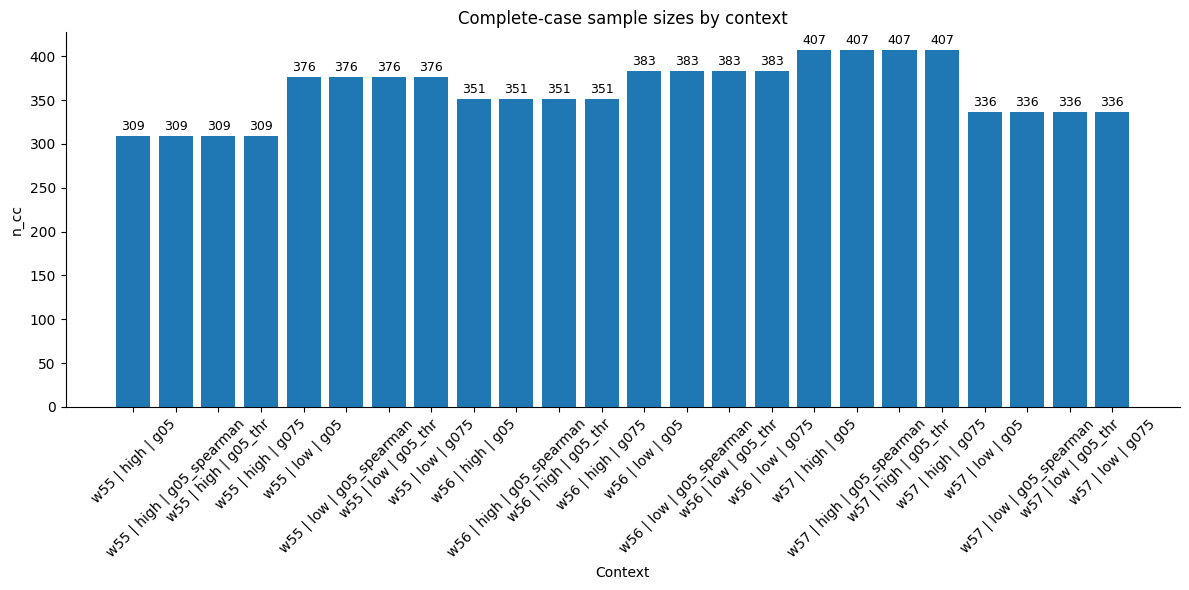

In [15]:
# ── Figure 01: sample sizes by context ───────────────────────────────────────
df = context_table.copy()
df["label"] = "w" + df["wave"].astype(str) + " | " + df["trust_stratum"] + " | " + df["spec"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df["label"], df["n_cc"])
ax.set_title("Complete-case sample sizes by context")
ax.set_xlabel("Context"); ax.set_ylabel("n_cc")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(df["n_cc"]):
    ax.text(i, v + df["n_cc"].max() * 0.01, str(v), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_01_sample_sizes_by_context.png", dpi=300, bbox_inches="tight")
plt.show()

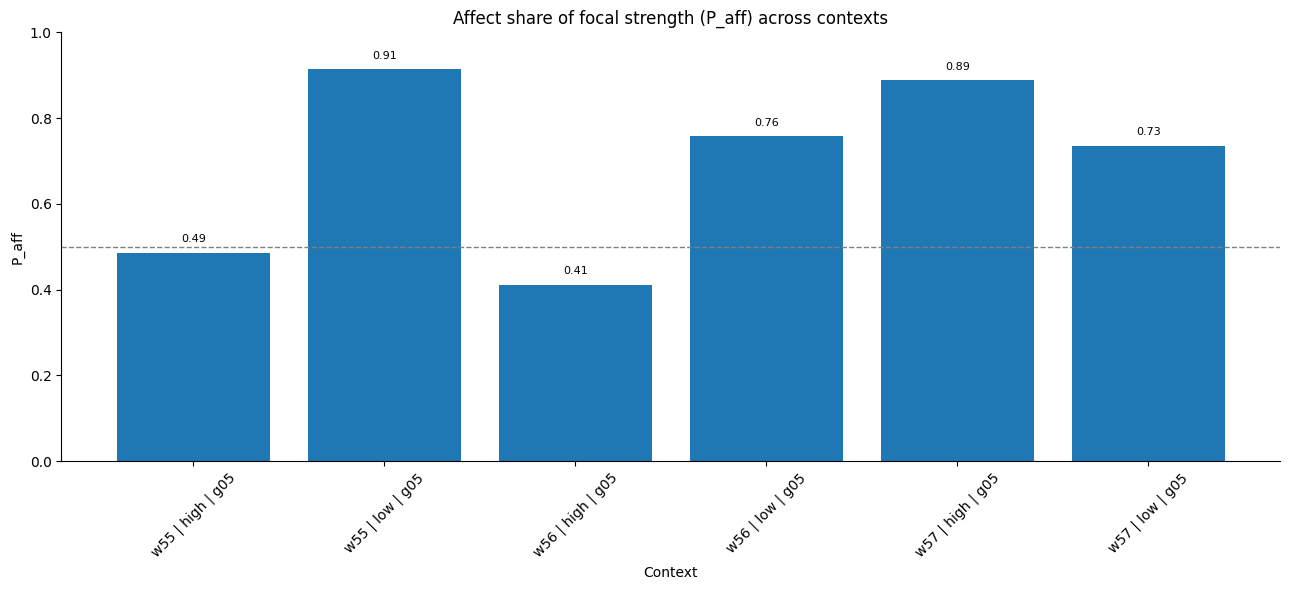

In [16]:
# ── Figure 03: affect share (P_aff) across contexts ─────────────────────────
df = embeddedness[embeddedness["spec"] == "g05"].sort_values(["wave","trust_stratum"]).reset_index(drop=True)
df["label"] = "w" + df["wave"].astype(str) + " | " + df["trust_stratum"] + " | " + df["spec"]

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(df["label"], df["P_aff"])
ax.axhline(0.5, linestyle="--", linewidth=1, color="grey")
ax.set_title("Affect share of focal strength (P_aff) across contexts")
ax.set_xlabel("Context"); ax.set_ylabel("P_aff")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(df["P_aff"]):
    if pd.notna(v):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_03_affect_share_by_context.png", dpi=300, bbox_inches="tight")
plt.show()

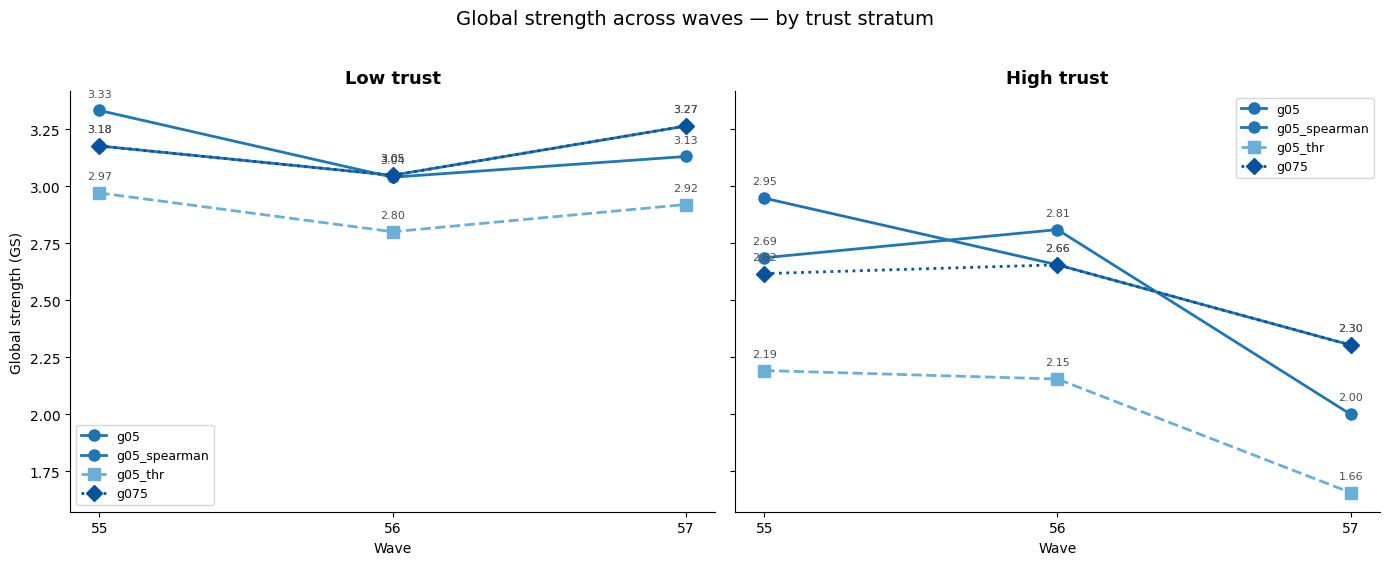

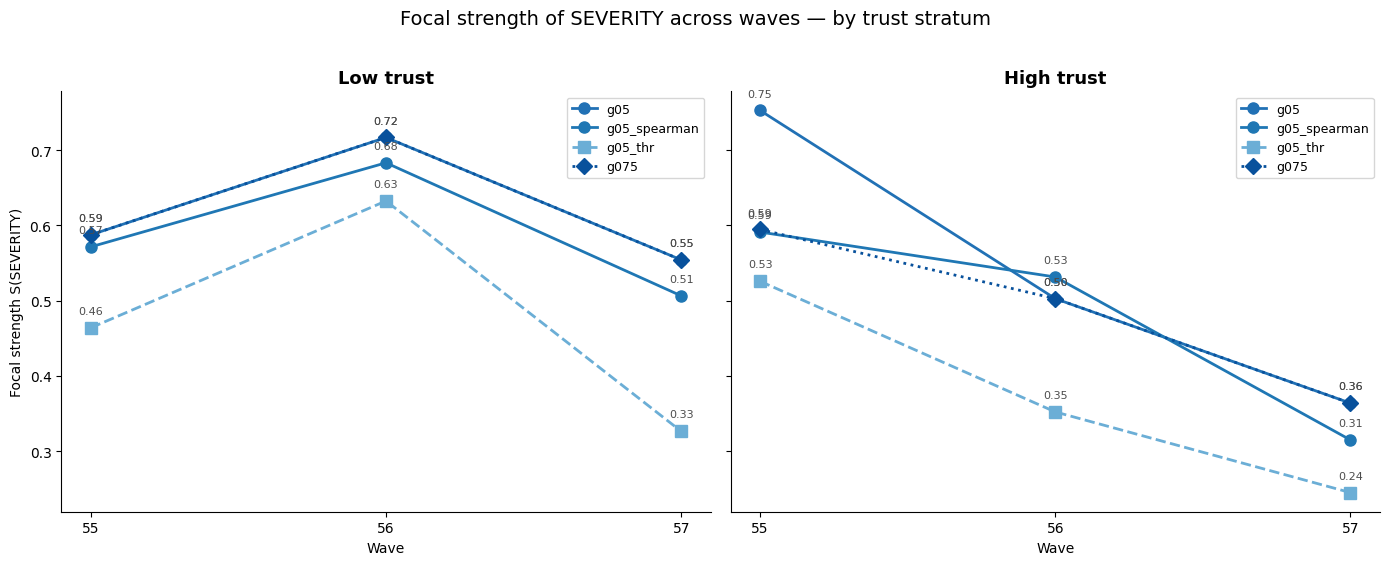

In [17]:
# ── Figure 04: Global strength across waves (split by trust) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
trust_labels = {"low": "Low trust", "high": "High trust"}
spec_styles  = {"g05": ("-", "o"), "g05_thr": ("--", "s"), "g075": (":", "D")}
spec_colors  = {"g05": "#2171b5", "g05_thr": "#6baed6", "g075": "#08519c"}

for ax, trust in zip(axes, ["low", "high"]):
    for spec in sorted(embeddedness["spec"].unique()):
        sub = (embeddedness
               .loc[(embeddedness["spec"] == spec) & (embeddedness["trust_stratum"] == trust)]
               .sort_values("wave"))
        ls, mk = spec_styles.get(spec, ("-", "o"))
        ax.plot(sub["wave"], sub["GS"], marker=mk, linestyle=ls,
                color=spec_colors.get(spec, None), label=spec, linewidth=2, markersize=8)
        for _, row in sub.iterrows():
            ax.annotate(f'{row["GS"]:.2f}', (row["wave"], row["GS"]),
                        textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8, color="0.3")
    ax.set_title(trust_labels[trust], fontsize=13, fontweight="bold")
    ax.set_xlabel("Wave"); ax.set_xticks(sorted(embeddedness["wave"].unique()))
    ax.legend(fontsize=9)

axes[0].set_ylabel("Global strength (GS)")
fig.suptitle("Global strength across waves — by trust stratum", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_04_global_strength_across_waves.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure 05: Focal strength across waves (split by trust) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, trust in zip(axes, ["low", "high"]):
    for spec in sorted(embeddedness["spec"].unique()):
        sub = (embeddedness
               .loc[(embeddedness["spec"] == spec) & (embeddedness["trust_stratum"] == trust)]
               .sort_values("wave"))
        ls, mk = spec_styles.get(spec, ("-", "o"))
        ax.plot(sub["wave"], sub["S_SEVERITY"], marker=mk, linestyle=ls,
                color=spec_colors.get(spec, None), label=spec, linewidth=2, markersize=8)
        for _, row in sub.iterrows():
            ax.annotate(f'{row["S_SEVERITY"]:.2f}', (row["wave"], row["S_SEVERITY"]),
                        textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8, color="0.3")
    ax.set_title(trust_labels[trust], fontsize=13, fontweight="bold")
    ax.set_xlabel("Wave"); ax.set_xticks(sorted(embeddedness["wave"].unique()))
    ax.legend(fontsize=9)

axes[0].set_ylabel("Focal strength S(SEVERITY)")
fig.suptitle("Focal strength of SEVERITY across waves — by trust stratum", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_05_focal_strength_across_waves.png", dpi=300, bbox_inches="tight")
plt.show()


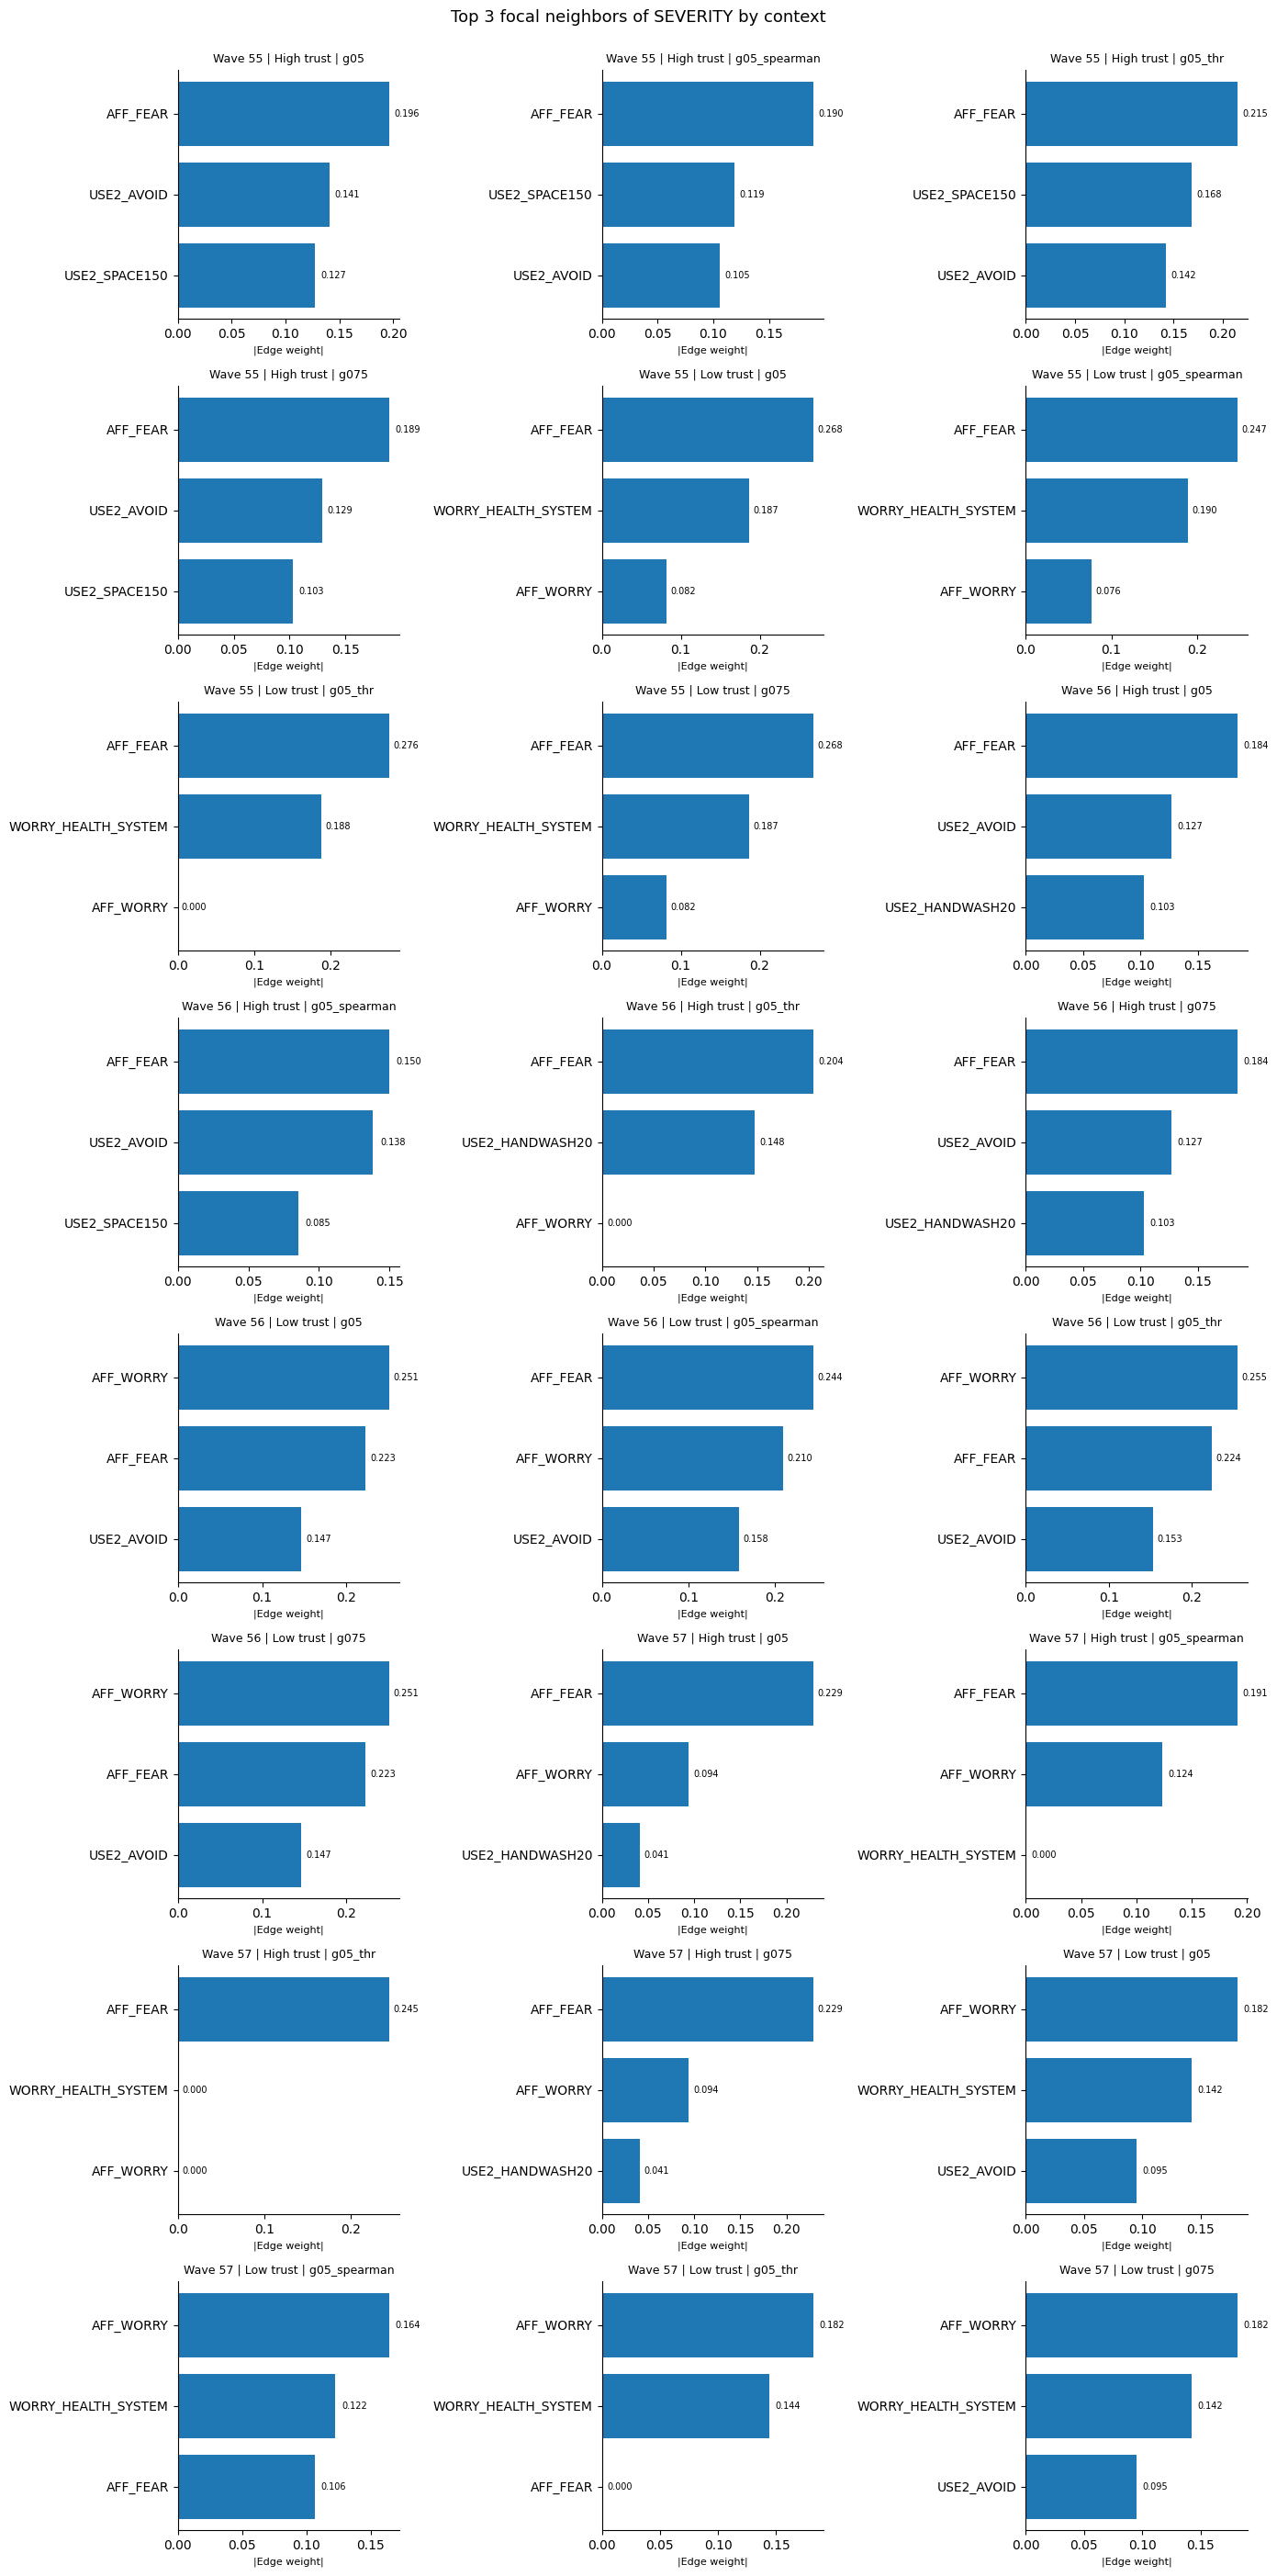

In [18]:
# ── Figure 07: top-3 focal neighbors per context (small multiples) ────────────
top3 = (
    focal_full[focal_full["focal_rank_within_context"] <= 3]
    .sort_values(["wave","trust_stratum","spec","focal_rank_within_context"])
    .reset_index(drop=True)
)
top3["context_label"] = (
    "Wave " + top3["wave"].astype(str)
    + " | " + top3["trust_stratum"].str.title() + " trust"
    + " | " + top3["spec"]
)

contexts = (
    top3[["wave","trust_stratum","spec","context_label"]]
    .drop_duplicates().sort_values(["wave","trust_stratum","spec"])
    ["context_label"].tolist()
)

ncols  = 3
nrows  = math.ceil(len(contexts) / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(14, max(6, nrows * 3.5)), sharex=False)
axes = axes.flatten()

for ax, ctx in zip(axes, contexts):
    sub = top3[top3["context_label"] == ctx].sort_values("abs_weight", ascending=True)
    ax.barh(sub["neighbor"], sub["abs_weight"])
    ax.set_title(ctx, fontsize=9)
    ax.set_xlabel("|Edge weight|", fontsize=8)
    for i, v in enumerate(sub["abs_weight"]):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=7)

for ax in axes[len(contexts):]:
    ax.axis("off")

fig.suptitle("Top 3 focal neighbors of SEVERITY by context", fontsize=13, y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_07_top3_focal_neighbors_by_context_bars.png",
            dpi=300, bbox_inches="tight")
plt.show()

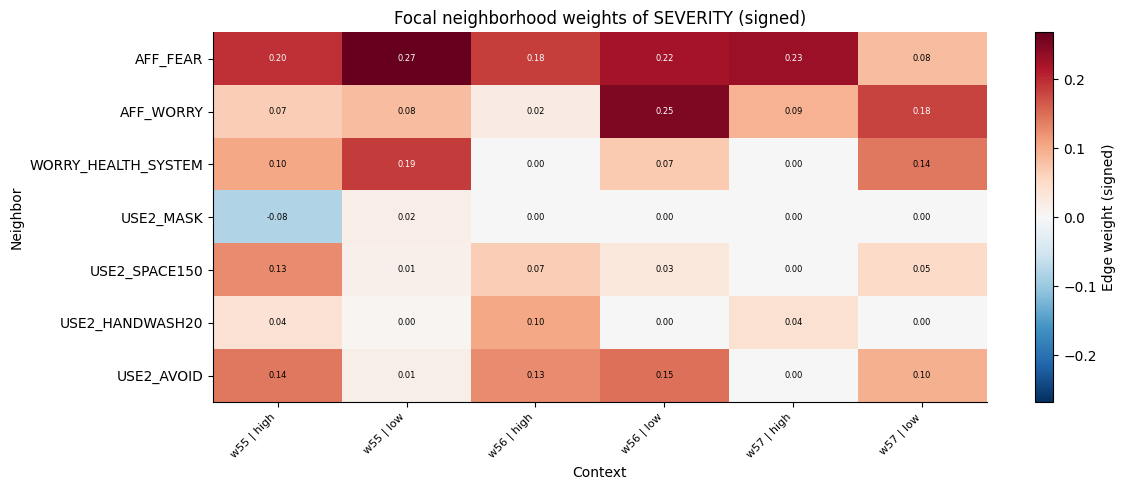

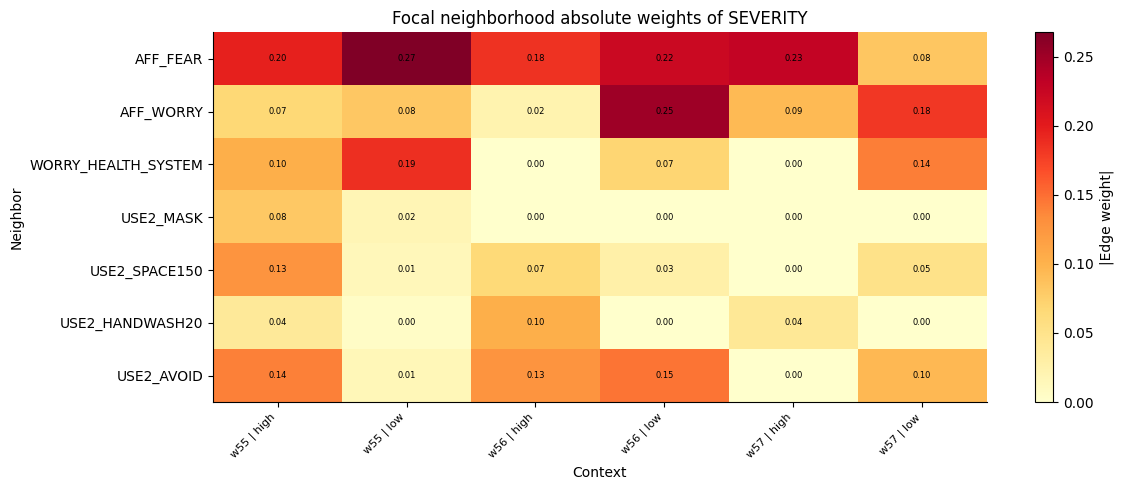

In [19]:
# ── Figures 08 & 09: focal neighborhood heatmaps (MAIN SPEC ONLY) ─────────────

NEIGHBOR_ORDER = [
    "AFF_FEAR","AFF_WORRY","WORRY_HEALTH_SYSTEM",
    "USE2_MASK","USE2_SPACE150","USE2_HANDWASH20","USE2_AVOID",
]

# --- FILTER TO MAIN SPECIFICATION (γ = 0.5) ---
heat_df = focal_full[focal_full["spec"] == "g05"].copy()

# --- CLEAN CONTEXT LABEL (NO SPEC) ---
heat_df["context_label"] = (
    "w" + heat_df["wave"].astype(str)
    + " | " + heat_df["trust_stratum"]
)

# --- ORDER CONTEXTS (WAVE × TRUST ONLY) ---
context_order = (
    heat_df[["wave","trust_stratum","context_label"]]
    .drop_duplicates()
    .sort_values(["wave","trust_stratum"])
    ["context_label"]
    .tolist()
)

# --- PLOTTING ---
for value_col, cmap, fname, cbar_label, title in [
    ("weight",
     "RdBu_r",
     "figure_08_focal_heatmap_weights.png",
     "Edge weight (signed)",
     "Focal neighborhood weights of SEVERITY (signed)"),
    ("abs_weight",
     "YlOrRd",
     "figure_09_focal_heatmap_absweights.png",
     "|Edge weight|",
     "Focal neighborhood absolute weights of SEVERITY"),
]:
    pivot = heat_df.pivot_table(
        index="neighbor",
        columns="context_label",
        values=value_col,
        aggfunc="first"
    ).reindex(index=NEIGHBOR_ORDER, columns=context_order)

    # --- COLOR SCALE ---
    vmax = float(pivot.abs().max().max()) if value_col == "weight" else None
    vmin = -vmax if value_col == "weight" else None

    # --- FIGURE ---
    fig, ax = plt.subplots(figsize=(max(12, len(context_order) * 0.9), 5))

    im = ax.imshow(
        pivot.values.astype(float),
        cmap=cmap,
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title)
    ax.set_xlabel("Context")
    ax.set_ylabel("Neighbor")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    # --- ANNOTATION ---
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            val = pivot.iloc[r, c]
            if pd.notna(val):
                ax.text(
                    c, r, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=6,
                    color="black" if (vmax is None or abs(val) < 0.6 * vmax) else "white"
                )

    fig.colorbar(im, ax=ax).set_label(cbar_label)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches="tight")
    plt.show()

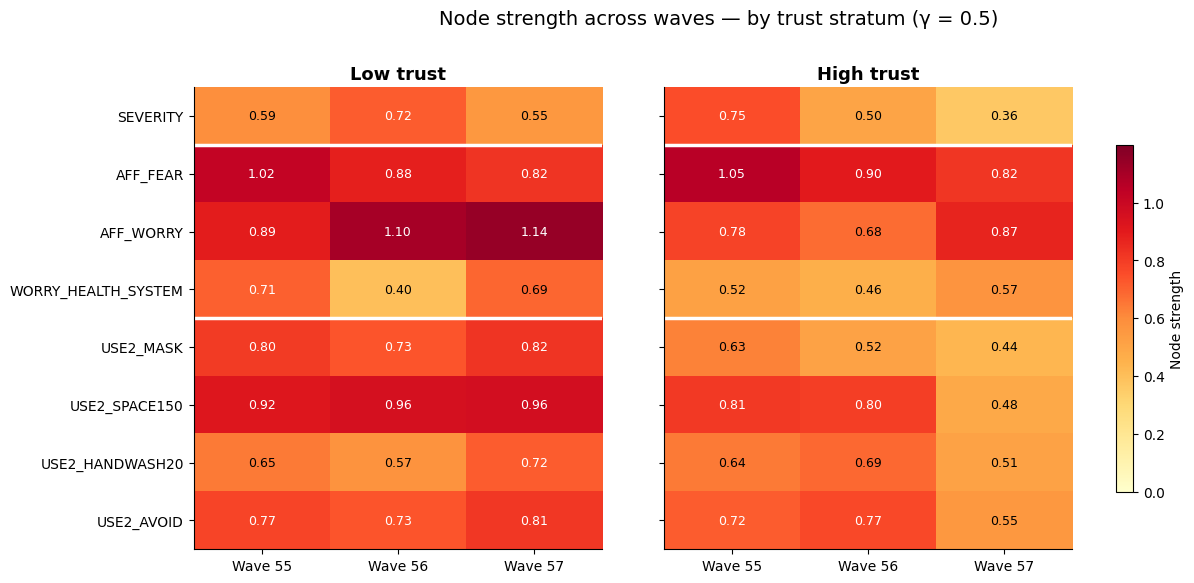

In [20]:
# ── Figure 10: Node strength heatmap — split by trust ────────────────────────
node_met = pd.read_csv(NETWORK_DIR / "node_metrics.csv")
n05 = node_met[node_met["spec"] == "g05"]

node_order = [
    "SEVERITY",
    "AFF_FEAR", "AFF_WORRY", "WORRY_HEALTH_SYSTEM",
    "USE2_MASK", "USE2_SPACE150", "USE2_HANDWASH20", "USE2_AVOID",
]
waves = [55, 56, 57]
wave_labels = [f"Wave {w}" for w in waves]

# Global color scale
all_vals = []
for trust in ["low", "high"]:
    for w in waves:
        sub = n05[(n05["wave"] == w) & (n05["trust_stratum"] == trust)]
        all_vals.extend(sub["strength"].tolist())
vmin, vmax = 0, max(all_vals) * 1.05

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         gridspec_kw={"width_ratios": [1, 1], "wspace": 0.15})

for ax, trust in zip(axes, ["low", "high"]):
    mat = np.full((len(node_order), len(waves)), np.nan)
    for j, w in enumerate(waves):
        sub = n05[(n05["wave"] == w) & (n05["trust_stratum"] == trust)]
        for ii, node in enumerate(node_order):
            row = sub[sub["node"] == node]
            if not row.empty:
                mat[ii, j] = row.iloc[0]["strength"]

    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(waves)))
    ax.set_xticklabels(wave_labels, fontsize=10)
    ax.set_title(f"{trust.title()} trust", fontsize=13, fontweight="bold")

    # Domain separators
    ax.axhline(0.5, color="white", linewidth=2.5)
    ax.axhline(3.5, color="white", linewidth=2.5)

    # Annotate
    for ii in range(mat.shape[0]):
        for jj in range(mat.shape[1]):
            if not np.isnan(mat[ii, jj]):
                c = "white" if mat[ii, jj] > 0.7 else "black"
                ax.text(jj, ii, f"{mat[ii, jj]:.2f}", ha="center", va="center",
                        fontsize=9, color=c)

axes[0].set_yticks(range(len(node_order)))
axes[0].set_yticklabels(node_order)
axes[1].set_yticks(range(len(node_order)))
axes[1].set_yticklabels([])

# Place colorbar to the right without overlapping
cbar = fig.colorbar(im, ax=axes.tolist(), label="Node strength",
                    shrink=0.75, pad=0.04)

fig.suptitle("Node strength across waves \u2014 by trust stratum (\u03b3 = 0.5)",
             fontsize=14, y=1.01)
fig.savefig(FIG_DIR / "figure_10_node_strength_heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()


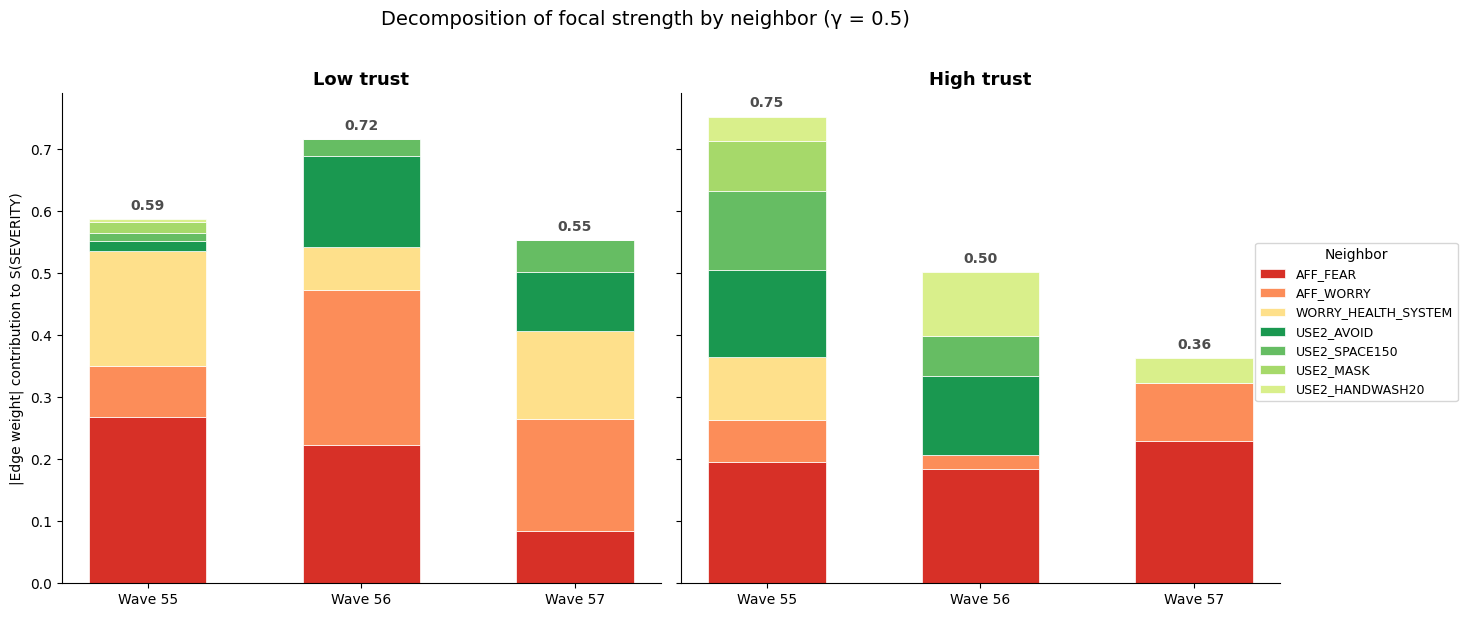

In [21]:
# ── Figure 11: Focal decomposition — split by trust ──────────────────────────
f05 = focal_full[focal_full["spec"] == "g05"].copy()
waves = [55, 56, 57]
wave_labels = [f"Wave {w}" for w in waves]

neighbor_order = [
    "AFF_FEAR", "AFF_WORRY", "WORRY_HEALTH_SYSTEM",
    "USE2_AVOID", "USE2_SPACE150", "USE2_MASK", "USE2_HANDWASH20",
]
domain_colors = {
    "AFF_FEAR":            "#d73027",
    "AFF_WORRY":           "#fc8d59",
    "WORRY_HEALTH_SYSTEM": "#fee08b",
    "USE2_AVOID":          "#1a9850",
    "USE2_SPACE150":       "#66bd63",
    "USE2_MASK":           "#a6d96a",
    "USE2_HANDWASH20":     "#d9ef8b",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, trust in zip(axes, ["low", "high"]):
    bar_data = []
    for w in waves:
        sub = f05[(f05["wave"] == w) & (f05["trust_stratum"] == trust)]
        vals = {}
        for n in neighbor_order:
            row = sub[sub["neighbor"] == n]
            vals[n] = row.iloc[0]["abs_weight"] if not row.empty else 0.0
        bar_data.append(vals)

    x = np.arange(len(waves))
    bottoms = np.zeros(len(waves))
    for n in neighbor_order:
        heights = [bd[n] for bd in bar_data]
        ax.bar(x, heights, bottom=bottoms, label=n, color=domain_colors[n],
               width=0.55, edgecolor="white", linewidth=0.5)
        bottoms += heights

    # Annotate totals
    for j, total in enumerate(bottoms):
        if total > 0:
            ax.text(j, total + 0.01, f"{total:.2f}", ha="center", va="bottom",
                    fontsize=10, fontweight="bold", color="0.3")

    ax.set_xticks(x)
    ax.set_xticklabels(wave_labels)
    ax.set_title(f"{trust.title()} trust", fontsize=13, fontweight="bold")

axes[0].set_ylabel("|Edge weight| contribution to S(SEVERITY)")

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", fontsize=9,
           title="Neighbor", title_fontsize=10, bbox_to_anchor=(1.13, 0.5))

fig.suptitle("Decomposition of focal strength by neighbor (\u03b3 = 0.5)",
             fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_11_focal_decomposition_by_neighbor.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [22]:
# ── Export manifests ──────────────────────────────────────────────────────────
CSV_EXPORTS = [
    "inventory_results_files.csv",
    "master_edges_all_contexts.csv",
    "focal_edges_severity.csv",
    "focal_summary_by_context.csv",
    "embeddedness_metrics_by_context.csv",
    "context_table_sample_sizes.csv",
    "trust_comparison_within_wave.csv",
    "wave_comparison_within_trust.csv",
    "focal_neighborhood_full.csv",
    "focal_neighborhood_full_rounded.csv",
    "insight_table_full.csv",
    "insight_table_full_rounded.csv",
    "top1_focal_neighbor_by_context.csv",
    "top1_focal_neighbor_by_context_rounded.csv",
]
export_manifest = pd.DataFrame({"file": CSV_EXPORTS})
export_manifest["exists"] = export_manifest["file"].apply(lambda x: (EXPORT_DIR / x).exists())
export_manifest.to_csv(EXPORT_DIR / "export_manifest.csv", index=False)

figure_manifest = pd.DataFrame({
    "figure_file": sorted(p.name for p in FIG_DIR.glob("*.png"))
})
figure_manifest["exists"] = True
figure_manifest.to_csv(EXPORT_DIR / "figure_manifest.csv", index=False)

# ── Final validation ──────────────────────────────────────────────────────────
missing_exports = export_manifest[~export_manifest["exists"]]
if not missing_exports.empty:
    print("\u26a0 Missing export files:")
    display(missing_exports)
else:
    print("\u2713 All", len(export_manifest), "CSV exports present.")

print("\u2713", len(figure_manifest), "figure(s) saved to:", FIG_DIR)
display(export_manifest)
display(figure_manifest)

✓ All 14 CSV exports present.
✓ 9 figure(s) saved to: C:\Users\Ciinz\Desktop\ThesisFinal\Results\networks\chapter_exports\figures


,file,exists
0,inventory_results_files.csv,True
1,master_edges_all_contexts.csv,True
2,focal_edges_severity.csv,True
3,focal_summary_by_context.csv,True
4,embeddedness_metrics_by_context.csv,True
5,context_table_sample_sizes.csv,True
6,trust_comparison_within_wave.csv,True
7,wave_comparison_within_trust.csv,True
8,focal_neighborhood_full.csv,True
9,focal_neighborhood_full_rounded.csv,True


,figure_file,exists
0,figure_01_sample_sizes_by_context.png,True
1,figure_03_affect_share_by_context.png,True
2,figure_04_global_strength_across_waves.png,True
3,figure_05_focal_strength_across_waves.png,True
4,figure_07_top3_focal_neighbors_by_context_bars...,True
5,figure_08_focal_heatmap_weights.png,True
6,figure_09_focal_heatmap_absweights.png,True
7,figure_10_node_strength_heatmap.png,True
8,figure_11_focal_decomposition_by_neighbor.png,True
